# News Dataset EDA

Lightweight exploratory analysis for parquet files in `data/raw`.
This notebook focuses on dataset inventory, schema quality, and one deep-dive dataset.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)


In [2]:
# Resolve raw data folder both for notebook execution from repo root and from notebooks/.
RAW_DIR = Path("data/raw").resolve()
if not RAW_DIR.exists():
    RAW_DIR = Path("../data/raw").resolve()

if not RAW_DIR.exists():
    raise FileNotFoundError("Cannot find data/raw. Run download notebook first.")

parquet_files = sorted(RAW_DIR.rglob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {RAW_DIR}")

symlink_files = [p for p in parquet_files if p.is_symlink()]
print(f"Raw dir: {RAW_DIR}")
print(f"Parquet files: {len(parquet_files)}")
print(f"Datasets: {len({p.parent.name for p in parquet_files})}")
print(f"Symlink parquet files: {len(symlink_files)}")
if symlink_files:
    print("Example symlink:", symlink_files[0])


Raw dir: /home/majestic/projects/OilOracle/data/raw
Parquet files: 131
Datasets: 24
Symlink parquet files: 0


In [3]:
# File-level inventory.
records = []
for file_path in parquet_files:
    records.append(
        {
            "dataset": file_path.parent.name,
            "file_name": file_path.name,
            "size_mb": file_path.stat().st_size / (1024 ** 2),
        }
    )

files_df = pd.DataFrame(records)
dataset_inventory = (
    files_df.groupby("dataset", as_index=False)
    .agg(file_count=("file_name", "count"), total_size_mb=("size_mb", "sum"))
    .sort_values(["total_size_mb", "file_count"], ascending=[False, False])
    .reset_index(drop=True)
)

display(dataset_inventory)


,dataset,file_count,total_size_mb
0,fnspid_news,59,10562.819479
1,all_the_news_2,4,3732.670219
2,bloomberg_reuters,17,1243.781461
3,american_news_jonasbecker,1,1001.211859
4,frontpage_news,10,971.128029
5,nyt_articles_2000_present,5,658.904806
6,us_financial_news_2018_jeet,1,438.097073
7,headlines_10sites_2007_2022,9,432.146699
8,yahoo_finance_articles,1,425.366627
9,nyt_headlines_1990_2020,6,252.591951


In [4]:
# Fast row-count estimation from parquet metadata.
# Uses pyarrow if available; otherwise keeps row_count as NaN.
try:
    import pyarrow.parquet as pq
except Exception:
    pq = None

row_counts = []
for file_path in parquet_files:
    row_count = np.nan
    if pq is not None:
        try:
            row_count = pq.ParquetFile(file_path).metadata.num_rows
        except Exception:
            row_count = np.nan

    row_counts.append(
        {
            "dataset": file_path.parent.name,
            "file_name": file_path.name,
            "row_count": row_count,
        }
    )

row_counts_df = pd.DataFrame(row_counts)
dataset_rows = (
    row_counts_df.groupby("dataset", as_index=False)
    .agg(rows_estimated=("row_count", "sum"))
)

dataset_overview = (
    dataset_inventory.merge(dataset_rows, on="dataset", how="left")
    .sort_values(["rows_estimated", "total_size_mb"], ascending=[False, False])
    .reset_index(drop=True)
)

display(dataset_overview)


,dataset,file_count,total_size_mb,rows_estimated
0,fnspid_news,59,10562.819479,28606801
1,bloomberg_reuters,17,1243.781461,8203282
2,frontpage_news,10,971.128029,4994950
3,headlines_10sites_2007_2022,9,432.146699,4405397
4,nyt_headlines_1990_2020,6,252.591951,2802355
5,nyt_articles_2000_present,5,658.904806,2175632
6,all_the_news_2,4,3732.670219,1972976
7,benzinga_6000stocks,4,162.318800,1568363
8,nyt_headlines_2010_2021,2,176.405776,597708
9,sentarl_combined,1,61.860703,318307


In [5]:
# Pick one dataset for a deeper EDA pass.
# Change TARGET_DATASET manually if needed.
TARGET_DATASET = "cnbc_headlines"
print("Target dataset:", TARGET_DATASET)

target_dir = RAW_DIR / TARGET_DATASET
target_files = sorted(target_dir.glob("*.parquet"))

parts = []
for file_path in target_files:
    parts.append(pd.read_parquet(file_path))

df = pd.concat(parts, ignore_index=True)
print(f"Loaded rows: {len(df):,} | columns: {df.shape[1]}")
display(df.head(3))


Target dataset: cnbc_headlines
Loaded rows: 553 | columns: 3


,date,text,extra_fields
0,2006-11-30T14:25:19Z,"Word On The Street: The Day Ahead\n\nTime for our look at the day ahead--with ""Word on the Street."" On this morning's ""Squawk On The Str...","{""author"":""Lee Brodie"",""publisher"":""CNBC"",""category"":""CNBC TV"",""url"":""https://www.cnbc.com/2006/11/30/word-on-the-street-the-day-ahead.h..."
1,2006-12-22T19:27:03Z,"Oil Extends Tumble From Three-Month High\n\nOil slipped further on Friday from a three-month high hit earlier in the week, as forecasts ...","{""author"":""cnbc.com"",""publisher"":""CNBC"",""category"":""Business News"",""url"":""https://www.cnbc.com/2006/12/22/oil-extends-tumble-from-threem..."
2,2007-01-31T20:09:30Z,Dollar Declines on Lack of Fed Rate Move\n\nThe dollar fell against the euro and yen on Wednesday after the Federal Reserve kept interes...,"{""author"":""Reuters"",""publisher"":""CNBC"",""category"":""Business News"",""url"":""https://www.cnbc.com/2007/01/31/dollar-declines-on-lack-of-fed-..."


In [6]:
# Column diagnostics.
quality_df = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=True),
    }
).sort_values(["missing_pct", "n_unique"], ascending=[False, True])

dup_pct = round(df.duplicated().mean() * 100, 2)
print(f"Duplicate row ratio: {dup_pct}%")
display(quality_df)


Duplicate row ratio: 0.0%


,dtype,missing_pct,n_unique
date,str,0.0,553
text,str,0.0,553
extra_fields,str,0.0,553


In [7]:
# Heuristic column detection for text/date profiling.
def choose_column(columns, candidates):
    normalized = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in normalized:
            return normalized[cand]
    return None

DATE_COL = choose_column(df.columns, ["date", "published_at", "publish_date", "datetime", "timestamp", "time"])
TEXT_COL = choose_column(df.columns, ["text", "content", "article", "body", "description", "headline", "title"])

print("DATE_COL:", DATE_COL)
print("TEXT_COL:", TEXT_COL)


DATE_COL: date
TEXT_COL: text


Valid parsed dates: 100.0%


/tmp/ipykernel_1400/263456035.py:13: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = pd.Series(ts).dt.to_period("M").value_counts().sort_index()


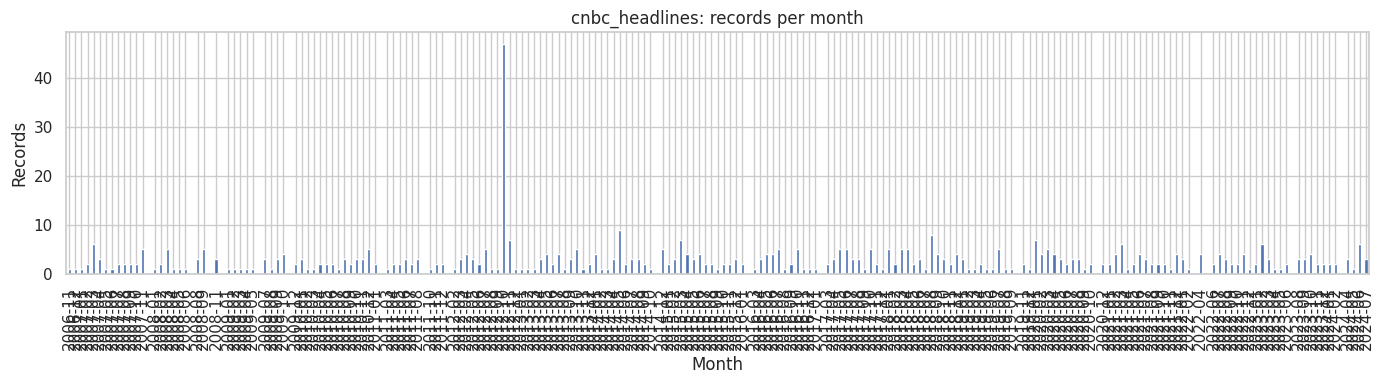

In [9]:
# Temporal profile.
if DATE_COL is None:
    print("No date-like column found.")
else:
    parsed_dates = pd.to_datetime(df[DATE_COL], errors="coerce", utc=True)
    valid_pct = (parsed_dates.notna().mean() * 100).round(2)
    print(f"Valid parsed dates: {valid_pct}%")

    ts = parsed_dates.dropna()
    if len(ts) == 0:
        print("All parsed dates are NaT.")
    else:
        monthly = pd.Series(ts).dt.to_period("M").value_counts().sort_index()
        ax = monthly.plot(kind="bar", figsize=(14, 4), title=f"{TARGET_DATASET}: records per month")
        ax.set_xlabel("Month")
        ax.set_ylabel("Records")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()


count          553.0
mean     3296.564195
std      2309.316206
min            176.0
50%           2858.0
90%           5748.4
95%           7114.2
99%         10016.88
max          28567.0
Name: text, dtype: Float64


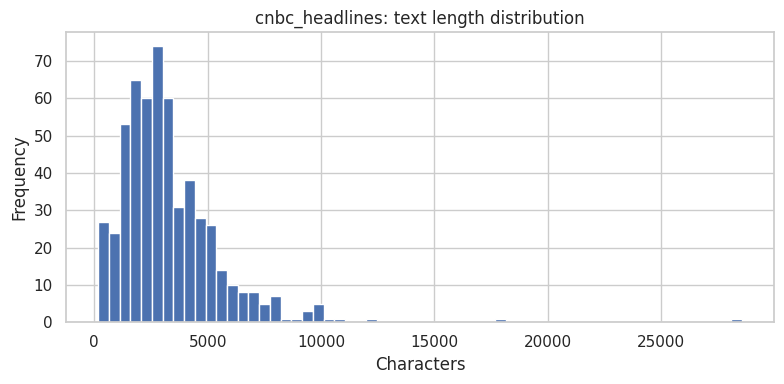

In [10]:
# Text-length profile.
if TEXT_COL is None:
    print("No text-like column found.")
else:
    text_len = df[TEXT_COL].astype("string").str.len()
    print(text_len.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(text_len.dropna(), bins=60)
    ax.set_title(f"{TARGET_DATASET}: {TEXT_COL} length distribution")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()
